# Breast Cancer Wisconsin (Diagnostic) Data Set 
## Data Exploration 

For this kernel, I will be exploring the Breast Cancer Wisconsin Data Set obtained through [Kaggle](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data), which is also available on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+%28Diagnostic%29).

According to the repository, this data set contains features computed from digitized images of cells extracted by a fine needle aspirate of a breast mass.  Each feature is a characteristic measured from the cell nuclei of cell masses from 569 patients.  The overall goal of this analysis is to train a learning algorithm that will be able to accurately classify cells into malignant and benign classes.



There are 32 features in total within this dataset, with one of them being the target feature (diagnosis).  

**Variable descriptions: **
 * 1) ID number 
 * 2) Diagnosis (M = malignant, B = benign) 
 * 3) - 32) For each of the following characteristics, 3 measurements (**mean**, **se**, **worst**) were computed for each cell nuclei:

    * radius (mean of distances from center to points on the perimeter) 
    * texture (standard deviation of gray-scale values) 
    * perimeter 
    * area 
    * smoothness (local variation in radius lengths) 
    * compactness (perimeter^2 / area - 1.0) 
    * concavity (severity of concave portions of the contour) 
    * concave points (number of concave portions of the contour) 
    * symmetry 
    * fractal dimension ("coastline approximation" - 1)

    The **mean**, **standard error** and "**worst**" or largest (mean of the three largest values) of these features were computed, resulting in 30 additional features. 

For this notebook, I aim to explore the data to get a grasp of what the data is showing and how different features are distributed. 

 ### Import Libraries 
 
 First I import some libraries to process the data into helpful formats. 

In [26]:
import numpy as np 
import pandas as pd 
import seaborn as sns  
import matplotlib.pyplot as plt 
%matplotlib inline

import os
print(os.listdir("../Breast-Cancer-Wisconsin-Dataset/"))

[' Breast Cancer Wisconsin Data Set - Classification.ipynb', ' Breast Cancer Wisconsin Data Set - Exploration.ipynb', '.git', '.ipynb_checkpoints', 'data.csv', 'README.md']


 ### Explore Data

Here, I look at the first few rows to see what features are present: 

In [27]:
data = pd.read_csv('data.csv')
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
id                         569 non-null int64
diagnosis                  569 non-null object
radius_mean                569 non-null float64
texture_mean               569 non-null float64
perimeter_mean             569 non-null float64
area_mean                  569 non-null float64
smoothness_mean            569 non-null float64
compactness_mean           569 non-null float64
concavity_mean             569 non-null float64
concave points_mean        569 non-null float64
symmetry_mean              569 non-null float64
fractal_dimension_mean     569 non-null float64
radius_se                  569 non-null float64
texture_se                 569 non-null float64
perimeter_se               569 non-null float64
area_se                    569 non-null float64
smoothness_se              569 non-null float64
compactness_se             569 non-null float64
concavity_se               569 non

In [29]:
data.iloc[:, 32].isnull().value_counts()

True    569
Name: Unnamed: 32, dtype: int64

From what I saw in `data.head()` and `data.info()`, a few things are of note: 
* 1) All features except `id`, `diagnosis`, and `Unnamed: 32` are non-null floating point numbers
* 2) `diagnosis` is an object variable containing two values: M or B, and will need to be converted to binary 
* 3) `id` is just an identification number, and is unlikely to hold any predictive power, and so should be dropped
* 4) `Unnamed: 32` is a column of NaN values, and so should be dropped

In [30]:
print(data.shape)

(569, 33)


A list of features can be captured by `data.columns`:

In [31]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [32]:
data.groupby('diagnosis').count()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
diagnosis,,,,,,,,,,,,,,,,,,,,,
B,357,357,357,357,357,357,357,357,357,357,...,357,357,357,357,357,357,357,357,357,0
M,212,212,212,212,212,212,212,212,212,212,...,212,212,212,212,212,212,212,212,212,0


Here I set the target feature as `y`, and the features we will use to classify our data as `x`.  I drop the uninformative columns: `id`, `diagnosis`, `Unnamed: 32` from `x`.

In [33]:
# Separate 'diagnosis' output and drop 'id', and 'Unnamed: 32' from input
y = data.diagnosis
x = data.drop(['id','diagnosis','Unnamed: 32'], axis = 1)

In [34]:
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


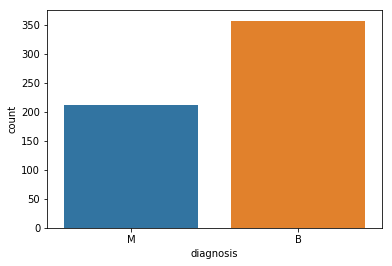

In [35]:
ax = sns.countplot(y);

There are 357 cases of benign tissue and 212 cases if malignant tissue within our dataset.  

In [36]:
x.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


I can see from `x.describe()` that there are wide differences in the range of the data across different features.  This suggests that I should scale and normalize the data so that they can be compared on the same scale.  

### Scale Data 

I scale the data using the `StandardScaler()` which mean normalizes each feature to 0 and divides it by the feature's unit variance.  

In [37]:
from sklearn.preprocessing import StandardScaler

# Standardize by removing mean and scaling by unit variance 
stdsc = StandardScaler()
noscaled_x = x
x = pd.DataFrame(stdsc.fit_transform(x), columns = x.columns)
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


Since three sets of measurements were acquired from the dataset (mean, SE, worst), I opted to plot each set separately for a more visually manageable comparison across the different features.

#### Mean features 
`data_m` will represent the data for the `mean` measurements: 

In [38]:
data_m = pd.concat([y, x.iloc[:, :10]], axis = 1)
data_m.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,M,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747
1,M,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652
2,M,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008
3,M,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919
4,M,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450


In [39]:
# melt data to structure into a format that can be fed into later plots 
data_m_melt = pd.melt(data_m, 
                 id_vars = 'diagnosis', 
                 var_name = 'features', 
                 value_name = 'value')
data_m_melt.head()

,diagnosis,features,value
0,M,radius_mean,1.097064
1,M,radius_mean,1.829821
2,M,radius_mean,1.579888
3,M,radius_mean,-0.768909
4,M,radius_mean,1.750297


#### SE features 

`data_se` will represent the data for the `se` measurements: 

In [40]:
data_se = pd.concat([y, x.iloc[:, 10:20]], axis = 1)
data_se.head()

,diagnosis,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se
0,M,2.489734,-0.565265,2.833031,2.487578,-0.214002,1.316862,0.724026,0.660820,1.148757,0.907083
1,M,0.499255,-0.876244,0.263327,0.742402,-0.605351,-0.692926,-0.440780,0.260162,-0.805450,-0.099444
2,M,1.228676,-0.780083,0.850928,1.181336,-0.297005,0.814974,0.213076,1.424827,0.237036,0.293559
3,M,0.326373,-0.110409,0.286593,-0.288378,0.689702,2.744280,0.819518,1.115007,4.732680,2.047511
4,M,1.270543,-0.790244,1.273189,1.190357,1.483067,-0.048520,0.828471,1.144205,-0.361092,0.499328


In [41]:
# melt data to structure into a format that can be fed into later plots 
data_se_melt = pd.melt(data_se, 
                  id_vars = 'diagnosis', 
                  var_name = 'features', 
                  value_name = 'value')
data_se_melt.head()

,diagnosis,features,value
0,M,radius_se,2.489734
1,M,radius_se,0.499255
2,M,radius_se,1.228676
3,M,radius_se,0.326373
4,M,radius_se,1.270543


#### Worst features 

`data_w` will represent the data for the `worst` measurements: 

In [42]:
data_w = pd.concat([y, x.iloc[:, 20:]], axis = 1)
data_w.head()

,diagnosis,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,M,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,M,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,M,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,M,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [43]:
# melt data to structure into a format that can be fed into later plots 
data_w_melt = pd.melt(data_w, 
                 id_vars = 'diagnosis', 
                 var_name = 'features', 
                 value_name = 'value')
data_w_melt.head()

,diagnosis,features,value
0,M,radius_worst,1.886690
1,M,radius_worst,1.805927
2,M,radius_worst,1.511870
3,M,radius_worst,-0.281464
4,M,radius_worst,1.298575


### Visualize Data


#### Violin Plots
Here I visualize the data using a violin plot for each set (mean, se, worst) of features. A violin plot displays the distribution of values of each feature for the two different classifications.  How widely the peaks are separated for each feature can be an indicator of which features may be most predictive for classifying the data. 

In [44]:
data_all_melt = {'Mean': data_m_melt, 'SE': data_se_melt, 'Worst': data_w_melt}

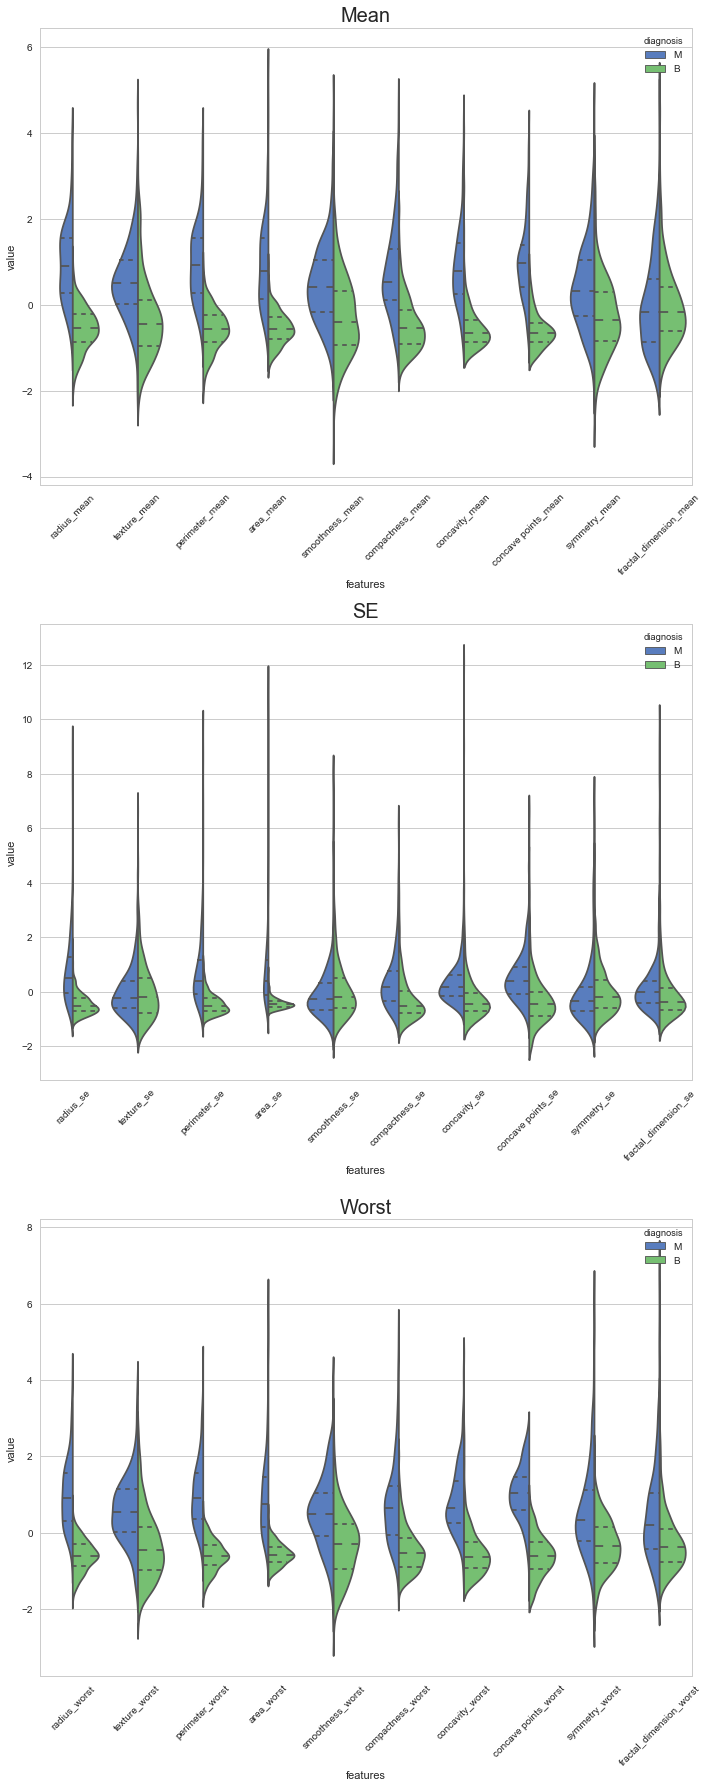

In [47]:
sns.set(style = 'whitegrid', palette = 'muted')
fig, axList = plt.subplots(nrows = 3, ncols = 1)
axList = axList.flatten()
fig.set_size_inches (10,25)
titles = ['Mean', 'SE', 'Worst']

for ax in enumerate(axList): 
    loc = ax[0]
    ax = ax[1]
    
    sns.violinplot(x = 'features', 
                   y = 'value', 
                   hue = 'diagnosis', 
                   data = data_all_melt[titles[loc]], 
                   ax = ax, 
                   inner = 'quart',
                   split = True)
    
    plt.sca(ax)
    plt.xticks(rotation = 45)
    ax.set_title(str(titles[loc]), fontsize = 20)
    
    plt.tight_layout()

In general, features like the perimeter, radius, and concave points have peaks that are well shifted between the malignant and benign groups, suggesting that malignant and benign tissue show distinct difference in these values for these features, and that they are among the most predictive for classification. 

#### Swarm Plots
Here I visualize the data using a swarm plot for each set (mean, se, worst) of features. A swarm plot is basically a scatterplot that will display how the data are distributed, and will be color-coded based on their classification.  Unlike the violin plot, the swarm plot can help us identify which features will give us the "cleanest split" (the clearest separation of the two classifications), and suggest the most predictive features for classification. 


In [ ]:
data_all = {'Mean': data_m, 'SE': data_se, 'Worst': data_w}

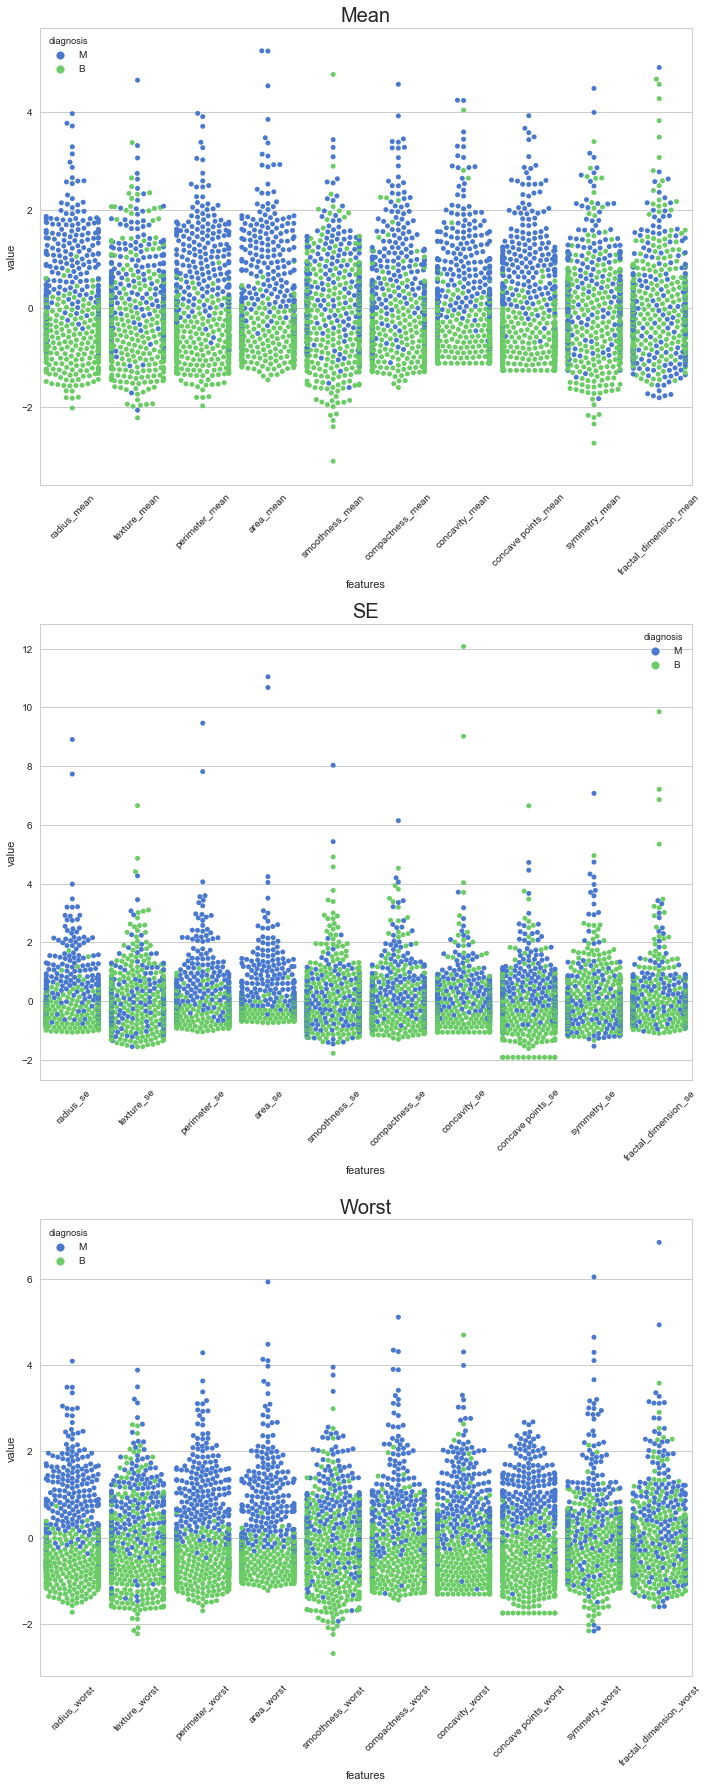

In [296]:
sns.set(style = 'whitegrid', palette = 'muted')

fig, axList = plt.subplots(nrows = 3, ncols = 1) 
axList = axList.flatten()
fig.set_size_inches(10,25)
titles = ['Mean', 'SE', 'Worst']

for ax in enumerate(axList): 
    loc = ax[0]
    ax = ax[1]
    
    sns.swarmplot(x = 'features', 
                  y = 'value', 
                  hue = 'diagnosis',
                  data = data_all[titles[loc]], 
                  ax = ax)

    plt.sca(ax)
    plt.xticks(rotation = 45)
    ax.set_title(str(titles[loc]), fontsize = 20)
    plt.tight_layout()

    

From the swarm plots, I can see that the mean and worst sets of features seems to offer the cleanest separation of the different classifications.  This is particularly the case for the features concave points, perimeter, area, and radius. So far, these two different visualizations suggest to me that concave points, perimeter, area, and radius are good features that offer good predictive potential. 

#### Correlation Plot 

Next I plot some correlation plots and heat maps to see if there are any highly correlated features that could be removed to prevent any potential overfitting. 

#### Mean

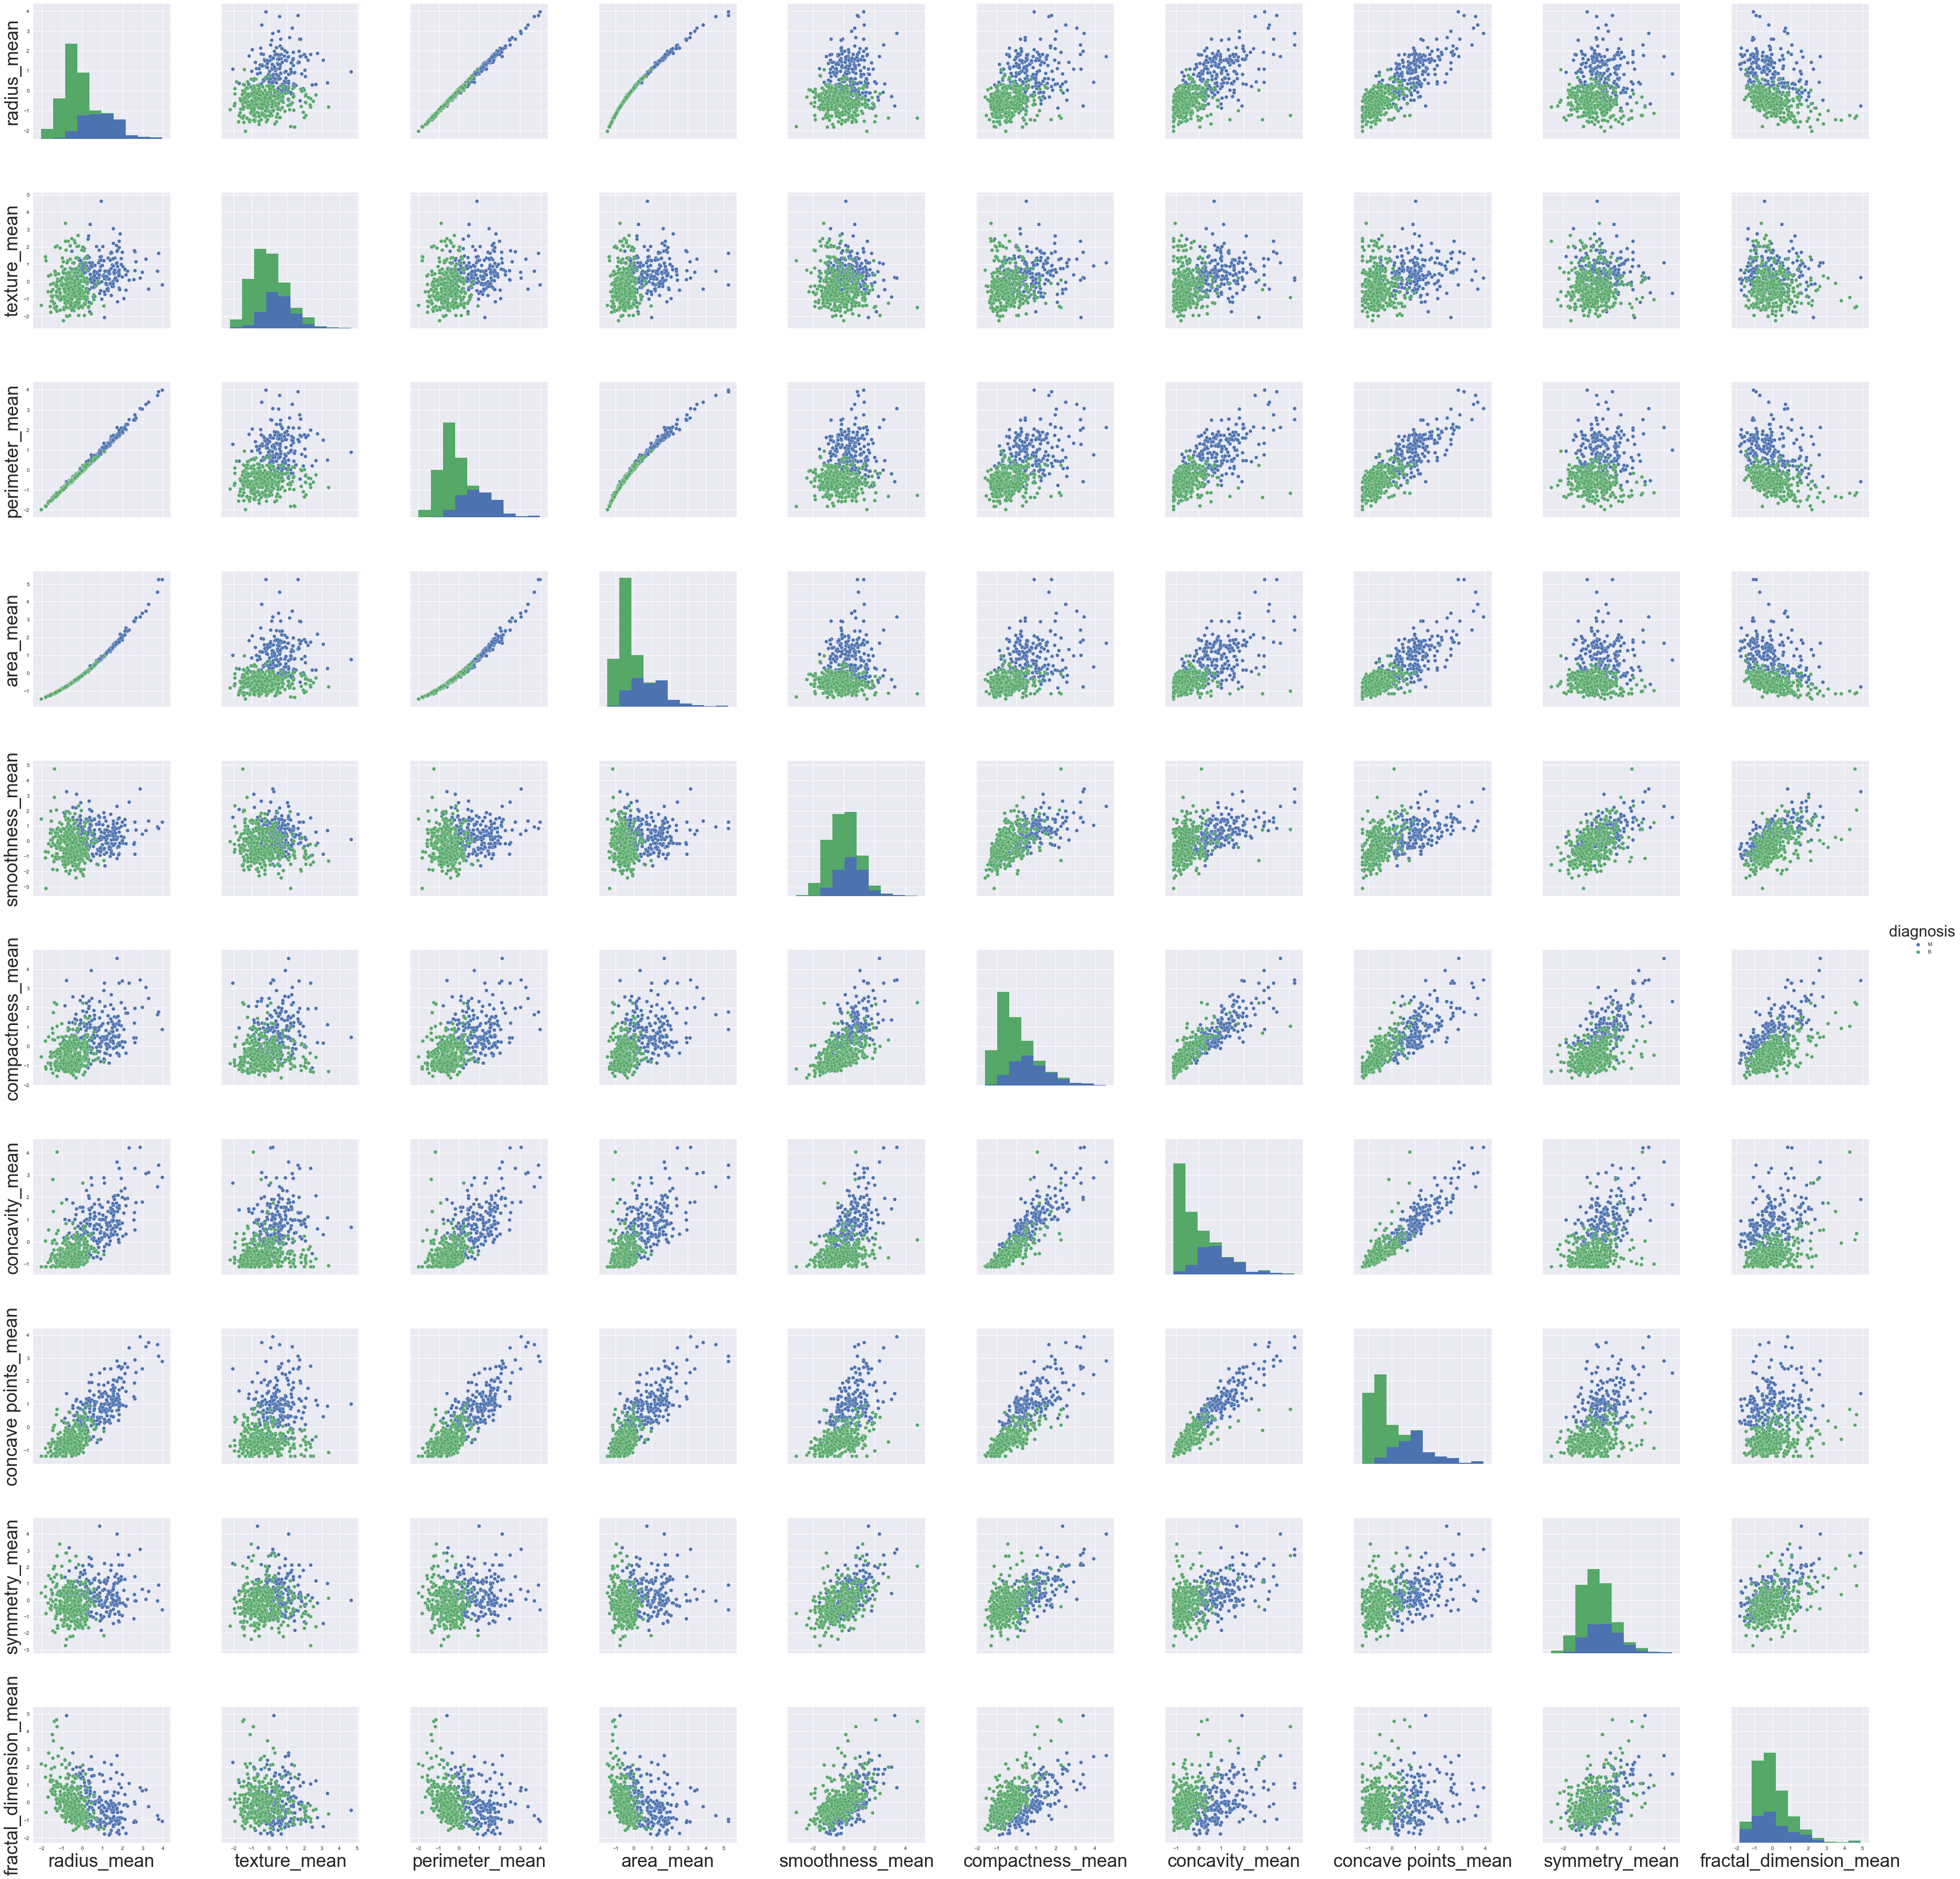

In [249]:
sns.set(rc = {'axes.labelsize': 35})
sns.pairplot(data_m, hue = 'diagnosis', size = 5);

#### SE

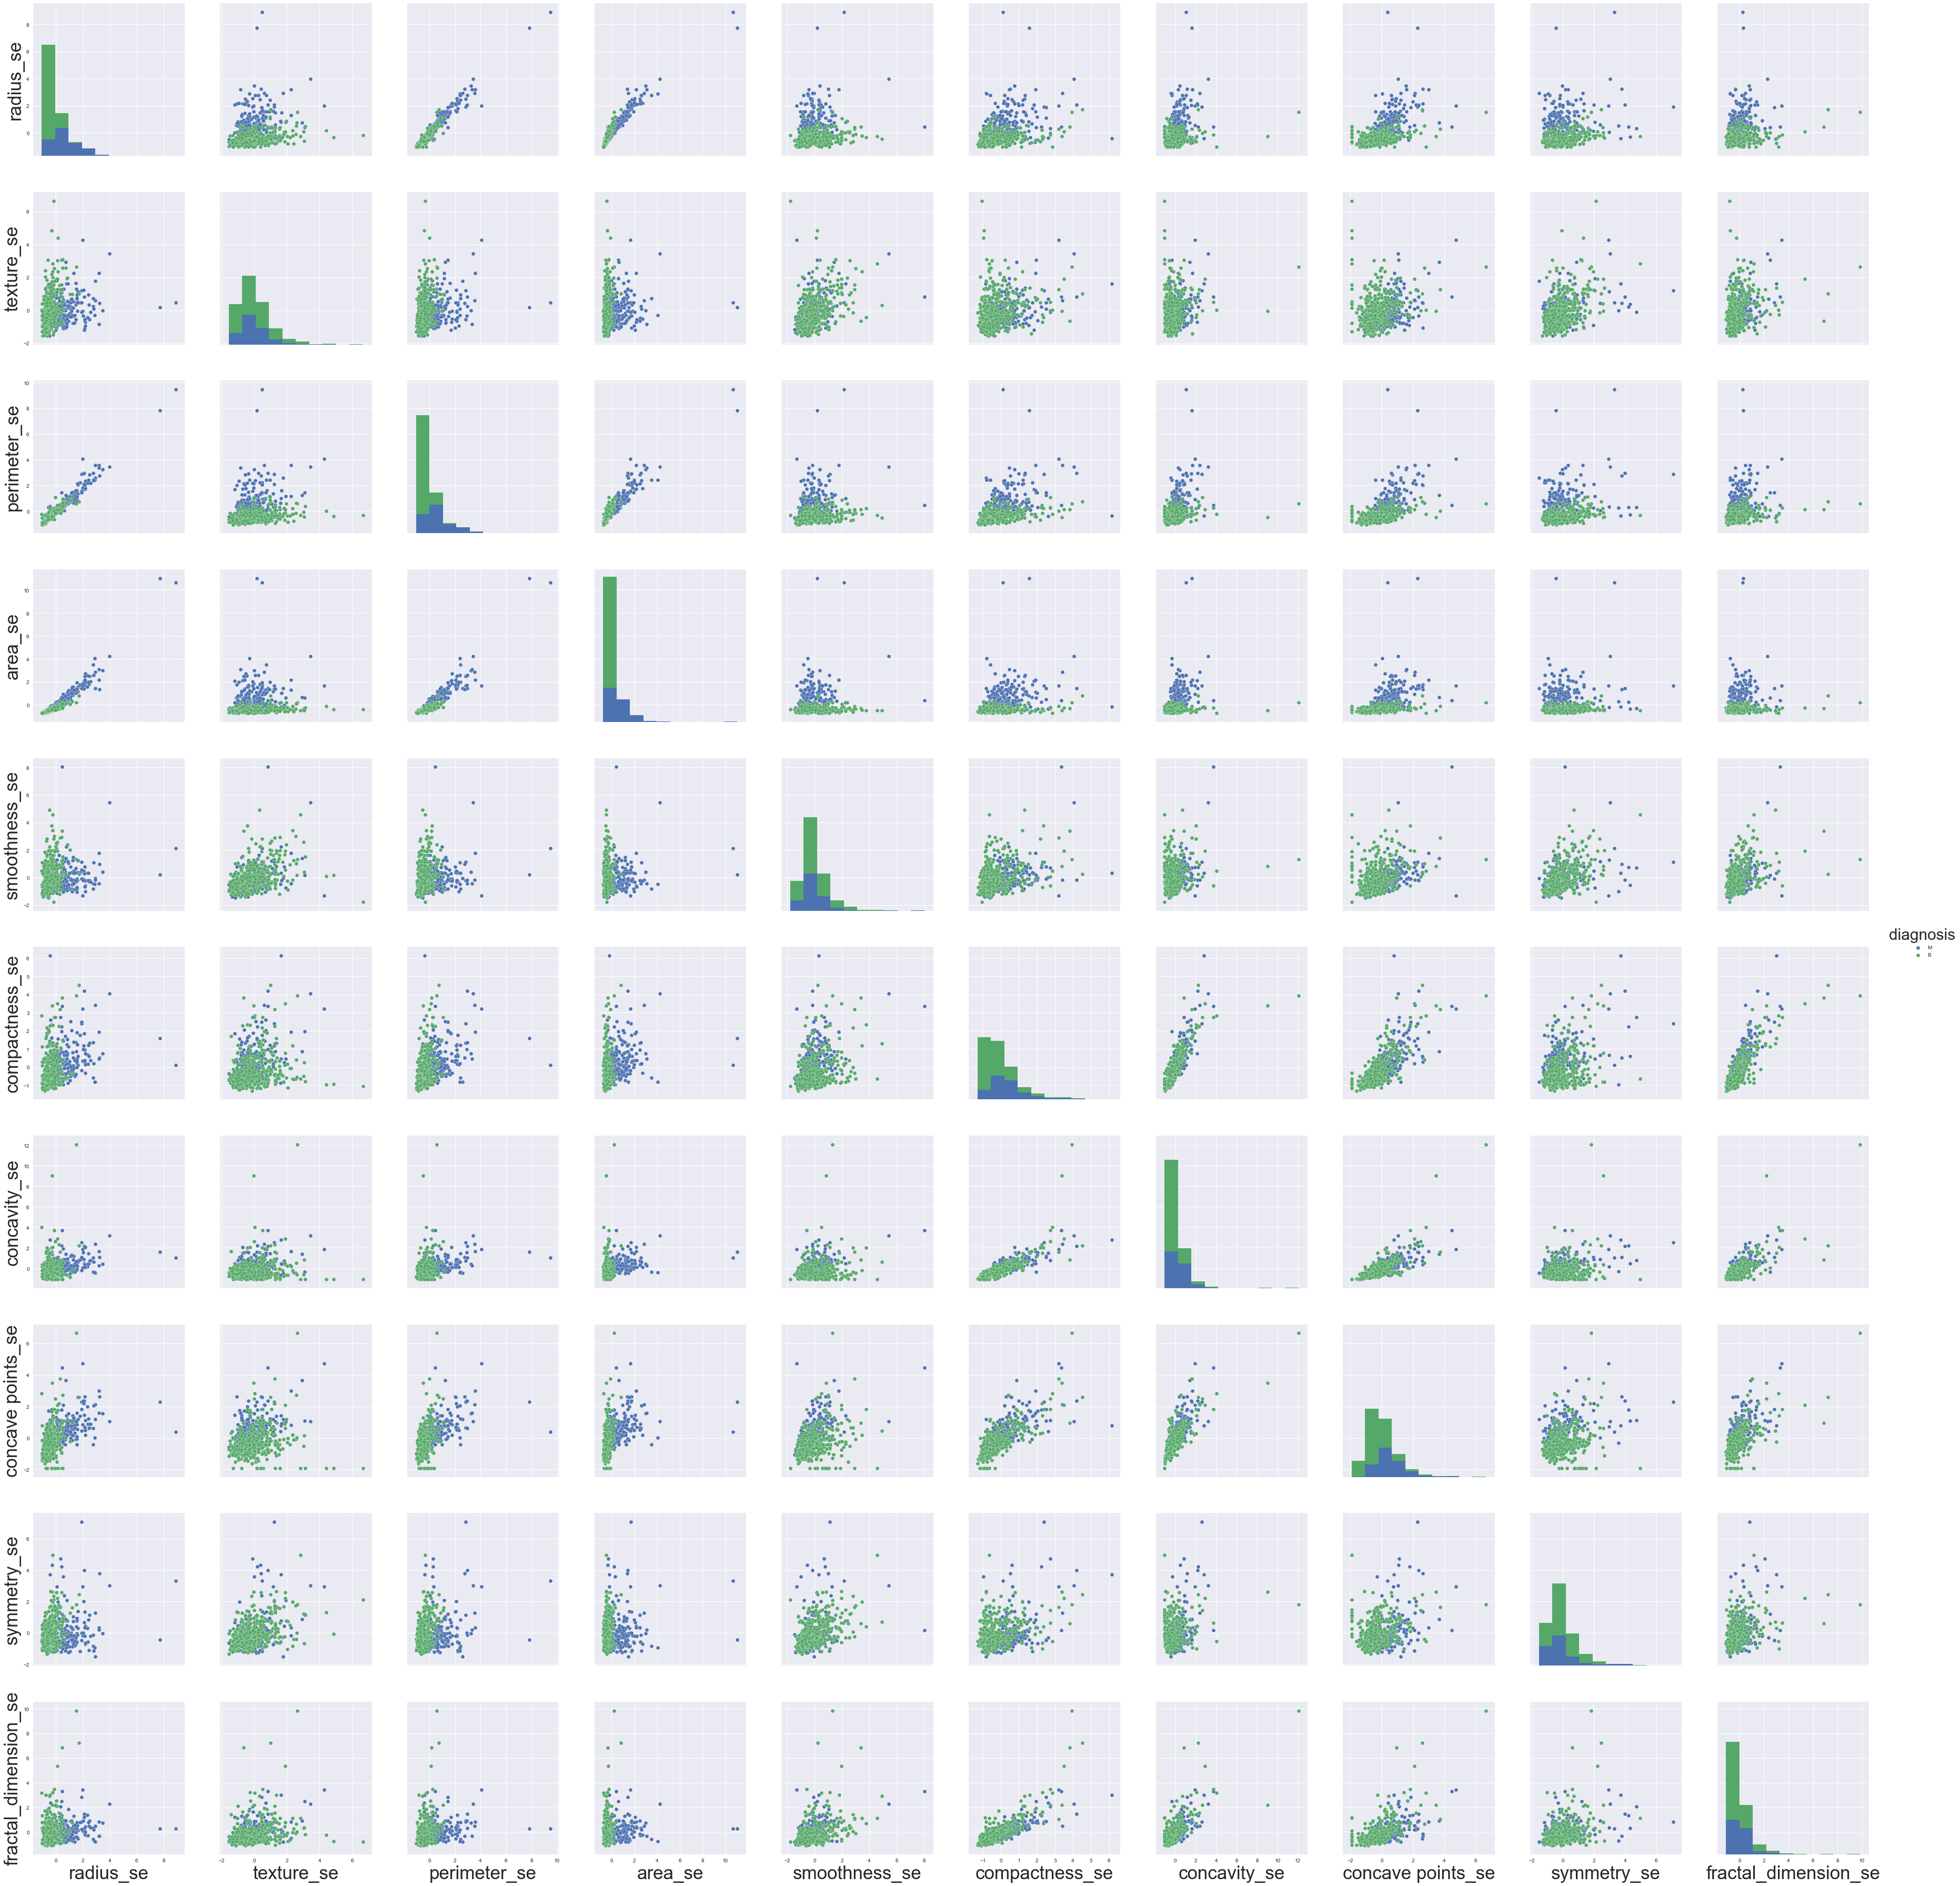

In [250]:
sns.pairplot(data_se, hue = 'diagnosis', size = 5);

#### Worst

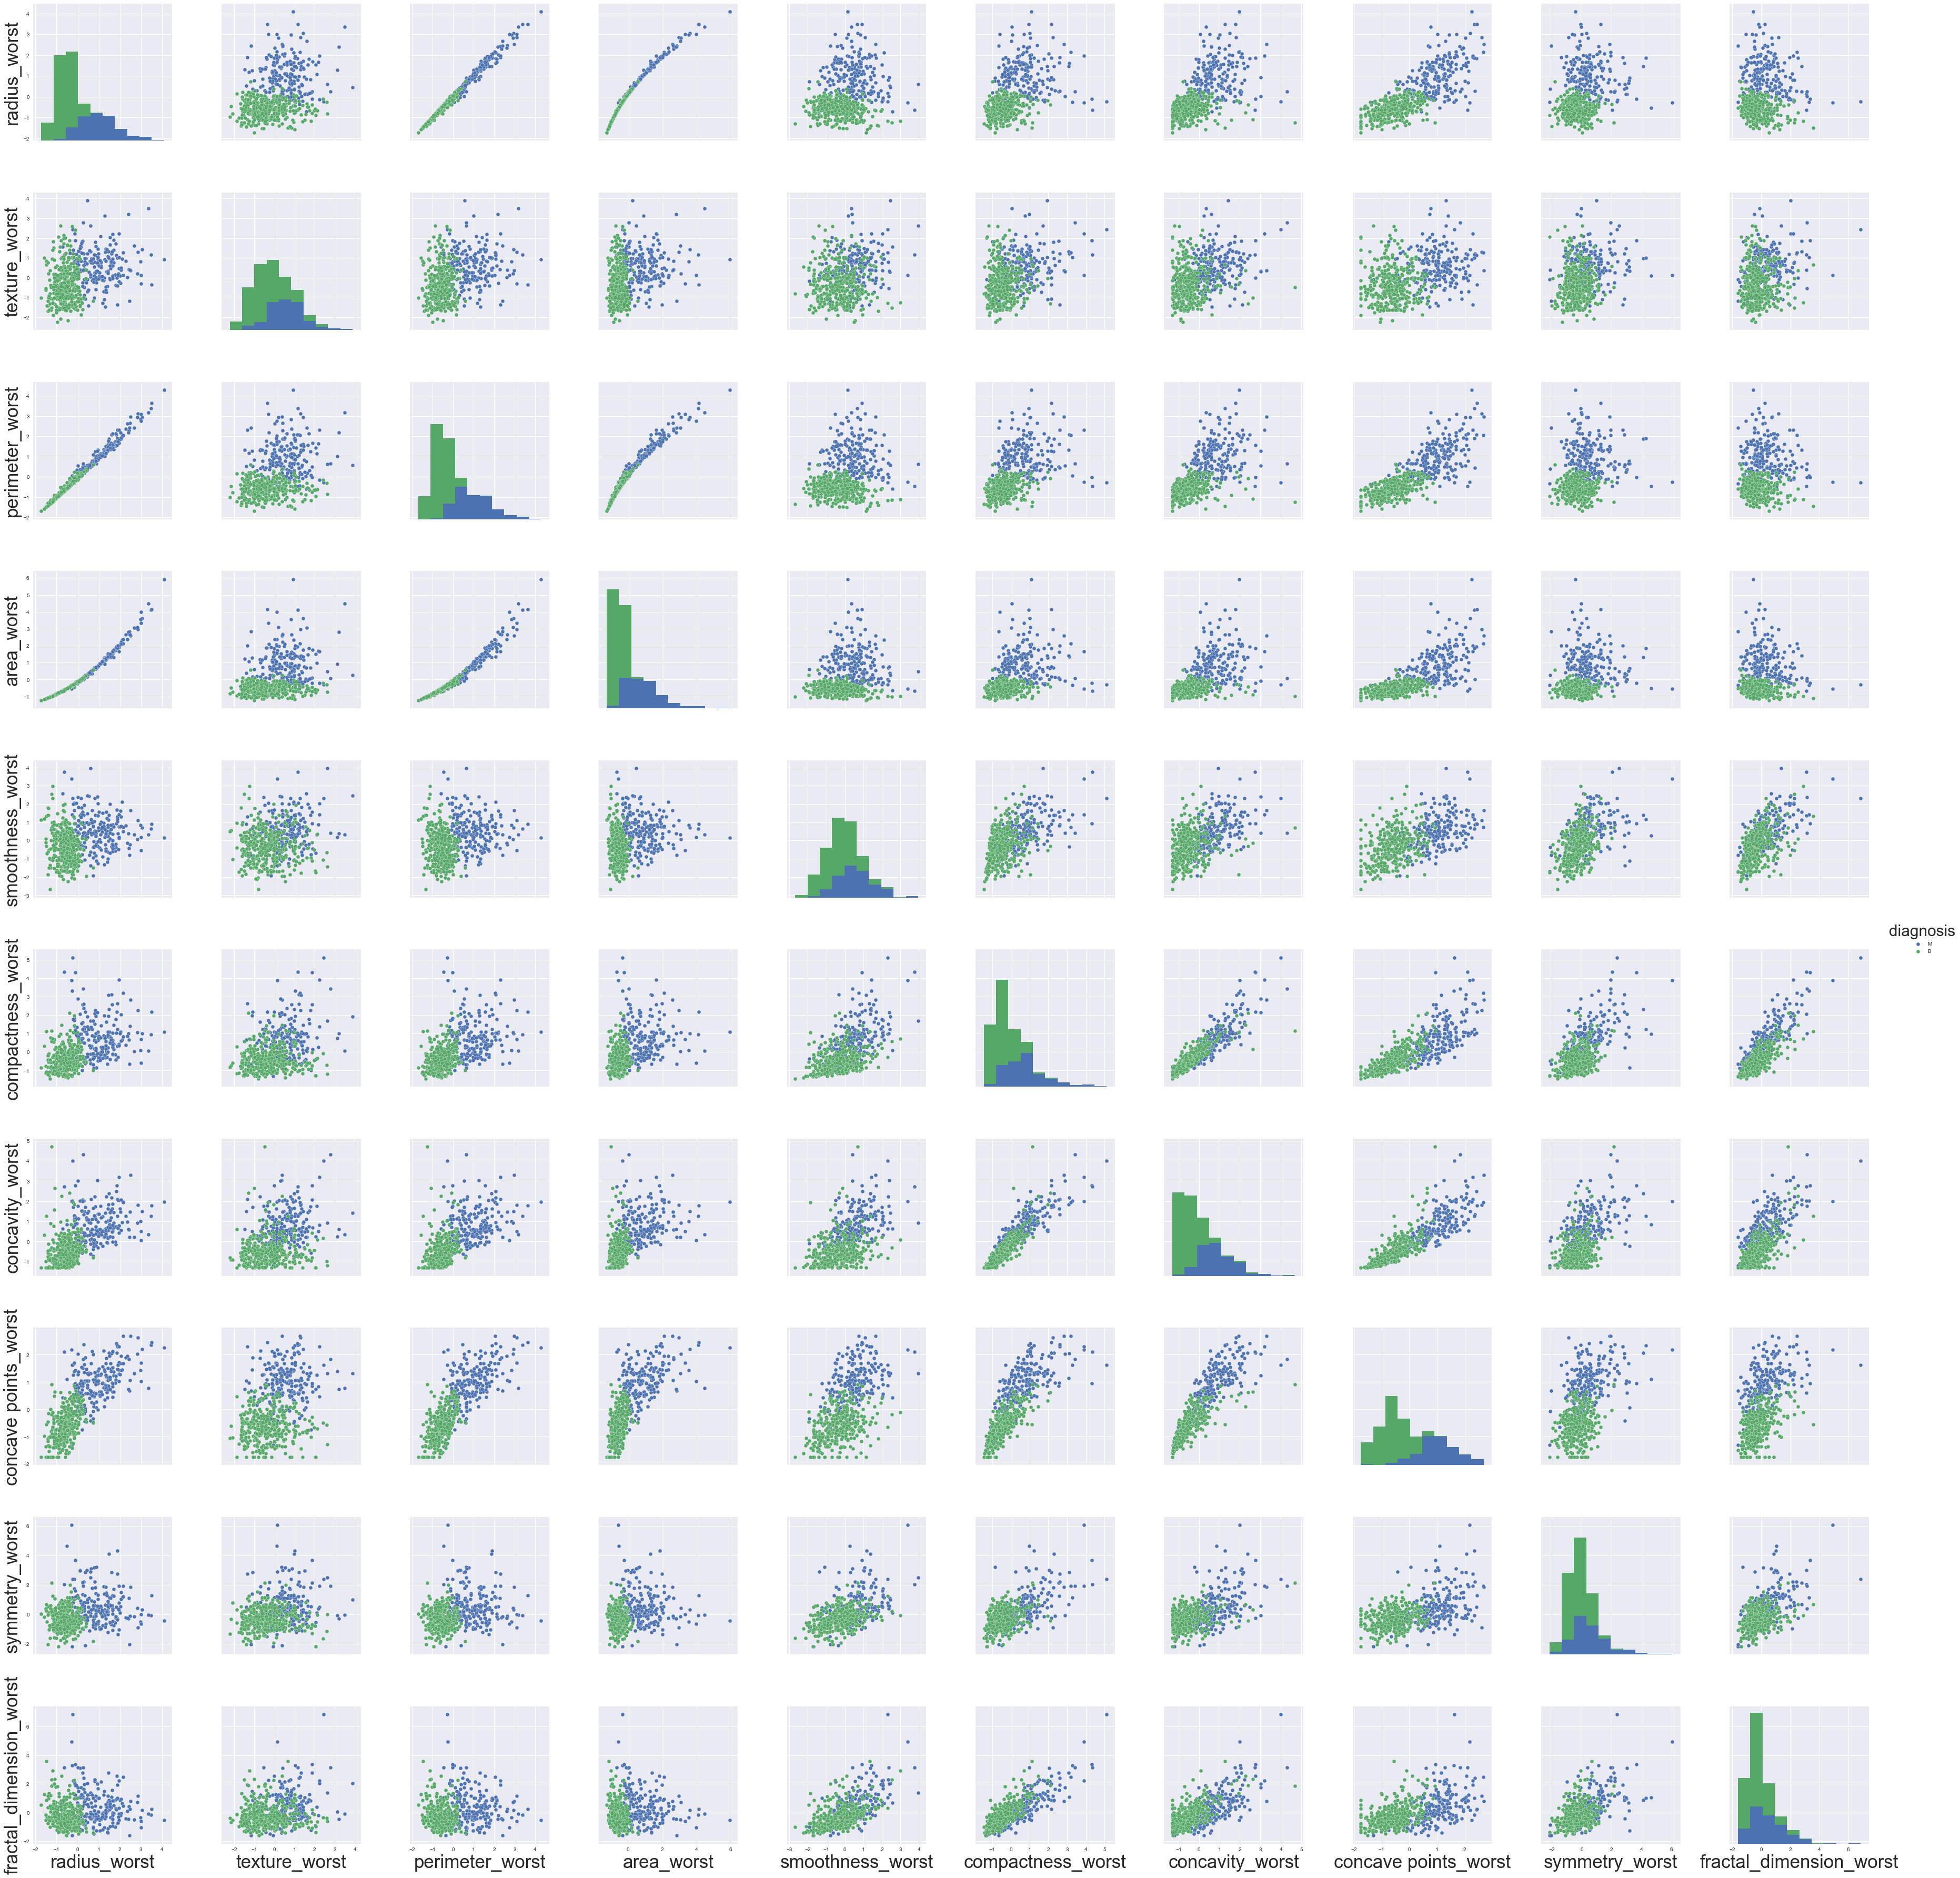

In [251]:
sns.pairplot(data_w, hue = 'diagnosis', size = 5);

#### Heat Map

Heat maps will color code each pairwise comparison of features based on the strength of the correlation (Pearson's correlation).  

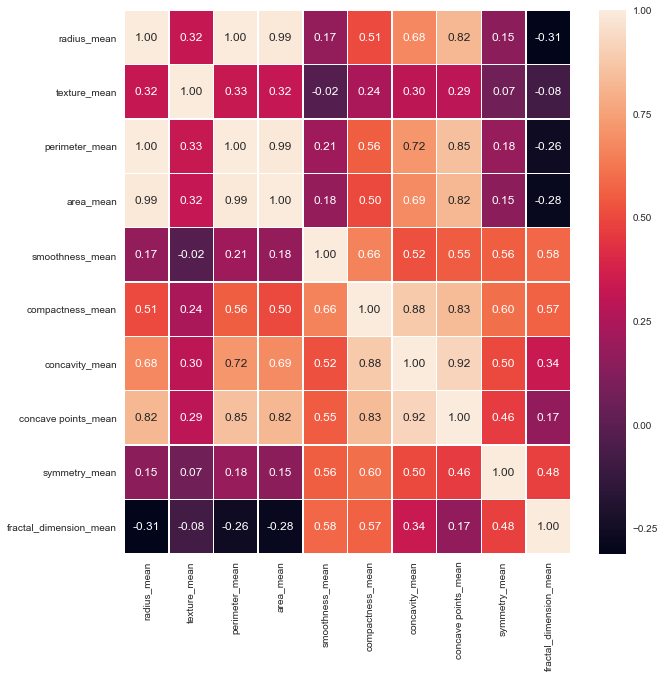

In [59]:
fig, ax = plt.subplots(figsize = (10,10))
sns.heatmap(data_m.corr(), linewidth = 0.5, annot = True, fmt = '.2f', ax = ax);

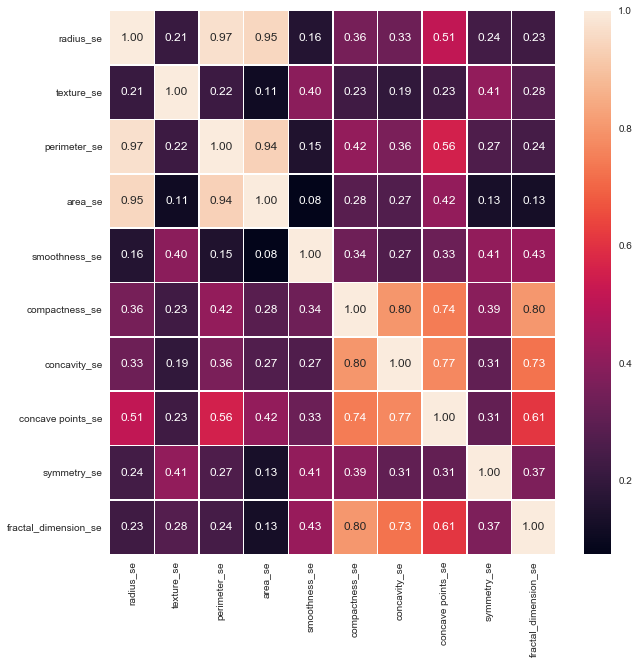

In [216]:
fig, ax = plt.subplots(figsize = (10,10))
sns.heatmap(data_se.corr(), linewidth = 0.5, annot = True, fmt = '.2f', ax = ax); 

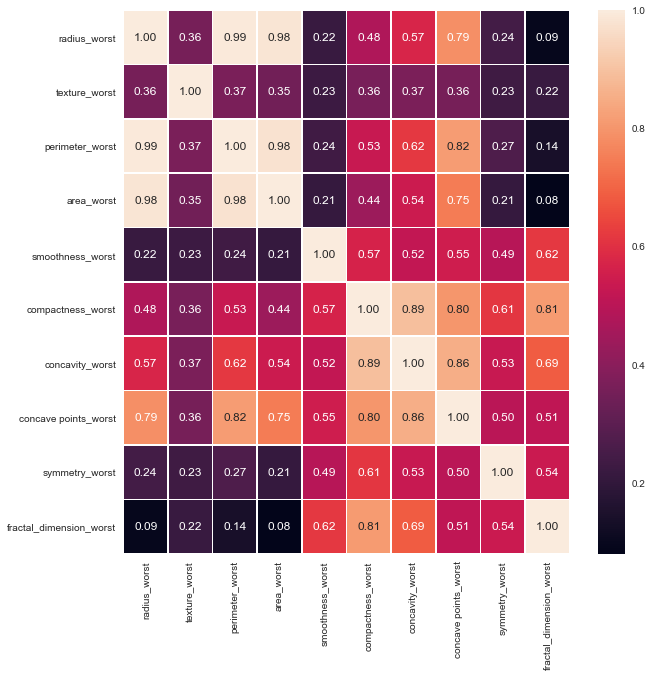

In [217]:
fig, ax = plt.subplots(figsize = (10,10))
sns.heatmap(data_w.corr(), linewidth = 0.5, annot = True, fmt = '.2f', ax = ax); 

Across all three sets, the features radius, perimeter, and area are strongly correlated with each other, as expected (since one can measure the area and perimeter if given the radius).  In case of overfitting, I can keep one of these features and remove the highly correlated ones. 

In the next notebook (Data Classification - Part II), I will train and tune different models on the data to develop a learning algorithm for classifying these cellular data into malignant and benign classes.  

#### Additional things (to be modified): 
Here is another classifier I've run using Random Forest to test what k value (for `SelectKBest`) offers the best accuracy. (to be merged with Classification Notebook as appropriate). 

In [48]:
x.head()
y.head()

0    M
1    M
2    M
3    M
4    M
Name: diagnosis, dtype: object

In [59]:
from sklearn import preprocessing
lb = preprocessing.LabelBinarizer()
y_lb = lb.fit_transform(y)
#y_lb = pd.DataFrame(data = lb.fit_transform(y), 
#                  columns = ['diagnosis'])
y_lb.ravel()

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1,

In [54]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(x, y_lb.ravel(), test_size = 0.3, random_state = 42)
x_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
149,-0.109996,-0.321053,-0.158542,-0.198772,-1.204139,-0.769070,-0.753164,-0.919018,-1.236277,-0.991984,...,-0.192419,-0.523905,-0.299980,-0.271919,-1.545592,-0.457162,-0.555498,-0.828574,-0.891002,-0.765061
124,-0.215082,-0.674768,-0.241747,-0.288361,-1.794101,-0.589220,-0.098925,-0.539588,-1.422476,-0.647506,...,-0.416068,-0.476680,-0.454866,-0.436812,-1.309316,-0.007411,0.281190,-0.378019,-1.379572,-0.424808
421,0.159817,-1.235591,0.257479,0.003444,0.479635,1.502076,0.705598,0.363201,1.001751,1.596561,...,0.039513,-1.194821,0.203699,-0.125485,-0.051226,0.694887,0.238492,-0.057956,-0.119321,0.450762
195,-0.345728,-0.688730,-0.388796,-0.393877,-1.206274,-0.960480,-0.628619,-0.648697,0.063458,-0.868652,...,-0.494759,-0.598813,-0.490013,-0.492186,-0.993698,-0.659455,-0.459548,-0.491153,0.199382,-0.801081
545,-0.144078,0.916946,-0.196849,-0.232332,-0.277565,-0.698760,-0.741488,-0.631673,-0.538947,-0.678694,...,-0.190348,0.555750,-0.288363,-0.265064,-0.472051,-0.652457,-0.802570,-0.652707,-0.418610,-0.798864


In [56]:
clf_rf = RandomForestClassifier(random_state = 43)
clf_rf = clf_rf.fit(x_train, y_train)
y_pred = clf_rf.predict(x_test)

ac = accuracy_score(y_test, clf_rf.predict(x_test))
f1 = f1_score(y_pred, y_test)
print (ac, f1) 

0.947368421053 0.928


In [57]:
from sklearn.feature_selection import SelectKBest 
from sklearn.feature_selection import f_classif

accuracy_k = []
f1_k = []

for i in range(30,0,-1): 
    select_feature = SelectKBest(f_classif, k = i).fit(x_train, y_train)

    x_train_2 = select_feature.transform(x_train)
    x_test_2 = select_feature.transform(x_test)

    clf_rf_2 = RandomForestClassifier(random_state = 43);
    clf_rf_2 = clf_rf_2.fit(x_train_2, y_train);
    y_pred_2 = clf_rf_2.predict(x_test_2);

    ac_2 = accuracy_score(y_test, clf_rf_2.predict(x_test_2));
    f1_2 = f1_2 = f1_score(y_pred_2, y_test);
    
    accuracy_k.append(ac_2) 
    f1_k.append(f1_2) 

metrics_dict = {'accuracy': accuracy_k, 'f1': f1_k}
metrics = pd.DataFrame(data = metrics_dict)


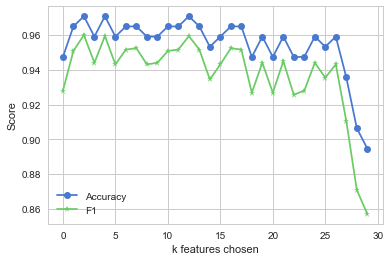

In [89]:
metrics
plt.plot(metrics.accuracy, marker = 'o');
plt.plot(metrics.f1, marker = '*');
plt.xlabel("k features chosen");
plt.ylabel("Score");
plt.legend(['Accuracy', 'F1'], loc = 0);


In [458]:
metrics

,accuracy,f1
0,0.947368,0.928000
1,0.964912,0.950820
2,0.970760,0.960000
3,0.959064,0.944000
4,0.970760,0.959350
5,0.959064,0.943089
6,0.964912,0.951613
7,0.964912,0.952381
8,0.959064,0.943089
9,0.959064,0.944000


In [462]:
#check out the skew of the data 
skew = pd.DataFrame(x.skew())
skew.columns = ['skew']
skew['too_skewed'] = skew['skew'] > 0.75
skew 

,skew,too_skewed
radius_mean,0.942380,True
texture_mean,0.650450,False
perimeter_mean,0.990650,True
area_mean,1.645732,True
smoothness_mean,0.456324,False
compactness_mean,1.190123,True
concavity_mean,1.401180,True
concave points_mean,1.171180,True
symmetry_mean,0.725609,False
fractal_dimension_mean,1.304489,True
